In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("C:/users/sydav/Downloads/sleep_health_dataset.csv")

In [3]:
print(df.head())

   person_id  age  gender         occupation   bmi country  \
0          1   29  Female             Driver  25.7   Japan   
1          2   55  Female  Software Engineer  22.0     USA   
2          3   42    Male              Nurse  25.0   India   
3          4   37  Female            Student  29.5   India   
4          5   23    Male             Lawyer  23.6   Spain   

   sleep_duration_hrs  sleep_quality_score  rem_percentage  \
0                6.19                  6.6            22.5   
1                8.32                  6.9            26.9   
2                3.74                  1.0            20.2   
3                6.79                  6.4            17.7   
4                5.02                  3.2            23.3   

   deep_sleep_percentage  ...  heart_rate_resting_bpm  sleep_aid_used  \
0                   19.3  ...                      63               0   
1                   14.9  ...                      52               1   
2                   16.2  ...      

In [4]:
print("\nShape of dataset:", df.shape)


Shape of dataset: (100000, 32)


In [5]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_sco

In [6]:
print("\nSleep Disorder Risk Values:")
print(df['sleep_disorder_risk'].value_counts())


Sleep Disorder Risk Values:
sleep_disorder_risk
Healthy     54156
Mild        33479
Moderate     8299
Severe       4066
Name: count, dtype: int64


In [7]:
# Convert target into binary

df['sleep_disorder_binary'] = df['sleep_disorder_risk'].apply(
    lambda x: 0 if x == 'Healthy' else 1
)

# Check converted values
print(df['sleep_disorder_binary'].value_counts())

sleep_disorder_binary
0    54156
1    45844
Name: count, dtype: int64


In [8]:
features = [
    'age',
    'bmi',
    'sleep_duration_hrs',
    'sleep_quality_score',
    'rem_percentage',
    'deep_sleep_percentage',
    'sleep_latency_mins',
    'wake_episodes_per_night',
    'caffeine_mg_before_bed',
    'alcohol_units_before_bed',
    'screen_time_before_bed_mins',
    'exercise_day',
    'steps_that_day',
    'nap_duration_mins',
    'stress_score',
    'work_hours_that_day',
    'heart_rate_resting_bpm',
    'sleep_aid_used',
    'shift_work',
    'room_temperature_celsius',
    'weekend_sleep_diff_hrs'
]

In [9]:
# Feature selection

X = df[features]

# Target column
y = df['sleep_disorder_binary']

# Display shapes
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (100000, 21)
Target Shape: (100000,)


### Train-Test Split + Scaling

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Display shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (70000, 21)
X_test shape: (30000, 21)
y_train shape: (70000,)
y_test shape: (30000,)


###  KNN Model

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Create model
knn = KNeighborsClassifier(n_neighbors=3)

# Train model
knn.fit(X_train, y_train)

# Predictions
y_pred_knn = knn.predict(X_test)

# Metrics
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

In [14]:
#  Results
print("KNN RESULTS")
print("Accuracy :", accuracy_knn)
print("Precision:", precision_knn)
print("Recall   :", recall_knn)
print("F1 Score :", f1_knn)

print("\nConfusion Matrix:\n")
print(cm_knn)

KNN RESULTS
Accuracy : 0.8018666666666666
Precision: 0.8142649669194771
Recall   : 0.7348186981214504
F1 Score : 0.7725045927740355

Confusion Matrix:

[[13964  2302]
 [ 3642 10092]]


In [15]:
TN, FP, FN, TP = cm_knn.ravel()

# True Positive Rate
TPR = TP / (TP + FN)

# False Positive Rate
FPR = FP / (FP + TN)

print("TPR:", TPR)
print("FPR:", FPR)

TPR: 0.7348186981214504
FPR: 0.14152219353252182


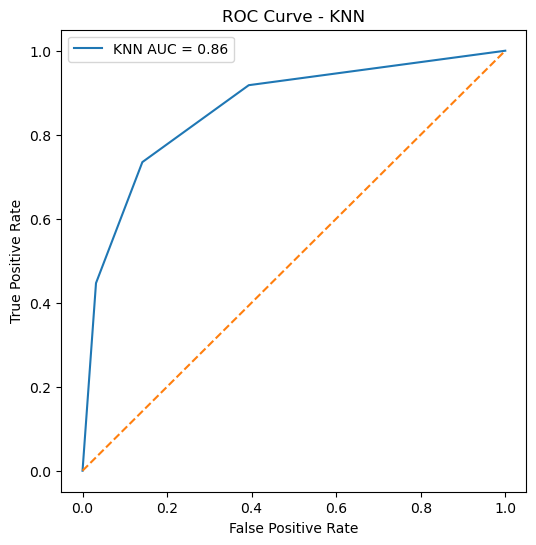

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability scores
y_prob_knn = knn.predict_proba(X_test)[:, 1]

# ROC values
fpr_knn, tpr_knn, thresholds = roc_curve(y_test, y_prob_knn)

# AUC score
auc_knn = roc_auc_score(y_test, y_prob_knn)

# Plot ROC Curve
plt.figure(figsize=(6,6))

plt.plot(fpr_knn, tpr_knn, label=f'KNN AUC = {auc_knn:.2f}')

# Random line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()

plt.show()

###  Naive Bayes

In [18]:
from sklearn.naive_bayes import GaussianNB

# Create model
nb = GaussianNB()

# Train model
nb.fit(X_train, y_train)

# Predictions
y_pred_nb = nb.predict(X_test)

# Metrics
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

In [19]:
#  Results
print("NAIVE BAYES RESULTS")
print("Accuracy :", accuracy_nb)
print("Precision:", precision_nb)
print("Recall   :", recall_nb)
print("F1 Score :", f1_nb)

print("\nConfusion Matrix:\n")
print(cm_nb)

NAIVE BAYES RESULTS
Accuracy : 0.8261666666666667
Precision: 0.8262234816573486
Recall   : 0.7854958497160333
F1 Score : 0.805345078571162

Confusion Matrix:

[[13997  2269]
 [ 2946 10788]]


In [20]:
TN, FP, FN, TP = cm_nb.ravel()

# True Positive Rate
TPR = TP / (TP + FN)

# False Positive Rate
FPR = FP / (FP + TN)

print("TPR:", TPR)
print("FPR:", FPR)

TPR: 0.7854958497160333
FPR: 0.1394934218615517


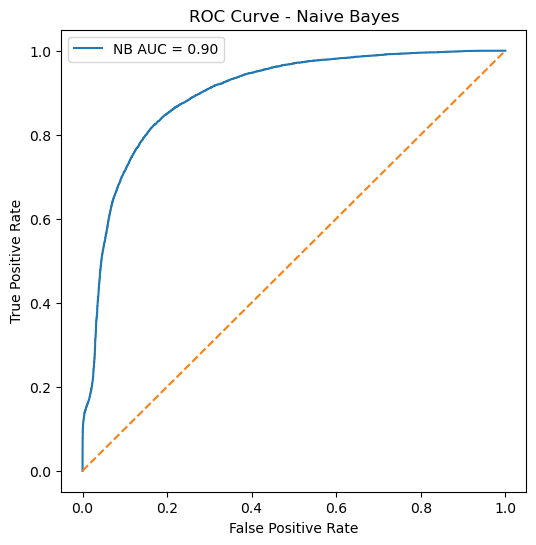

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability scores
y_prob_nb = nb.predict_proba(X_test)[:, 1]

# ROC values
fpr_nb, tpr_nb, thresholds = roc_curve(y_test, y_prob_nb)

# AUC score
auc_nb = roc_auc_score(y_test, y_prob_nb)

# Plot ROC Curve
plt.figure(figsize=(6,6))

plt.plot(fpr_nb, tpr_nb, label=f'NB AUC = {auc_nb:.2f}')

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend()

plt.show()

### SVM 

In [23]:
from sklearn.svm import LinearSVC

# Create model
svm = LinearSVC(max_iter=5000)

# Train model
svm.fit(X_train, y_train)

# Predictions
y_pred_svm = svm.predict(X_test)

# Metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

In [ ]:
# Results
print("SVM RESULTS")
print("Accuracy :", accuracy_svm)
print("Precision:", precision_svm)
print("Recall   :", recall_svm)
print("F1 Score :", f1_svm)

print("\nConfusion Matrix:\n")
print(cm_svm)

SVM RESULTS
Accuracy : 0.8451333333333333
Precision: 0.8345604476513032
Recall   : 0.8253240133974079
F1 Score : 0.8299165324352028

Confusion Matrix:

[[14019  2247]
 [ 2399 11335]]


In [46]:
TN, FP, FN, TP = cm_svm.ravel()

# True Positive Rate
TPR = TP / (TP + FN)

# False Positive Rate
FPR = FP / (FP + TN)

print("TPR:", TPR)
print("FPR:", FPR)

TPR: 0.8253240133974079
FPR: 0.1381409074142383


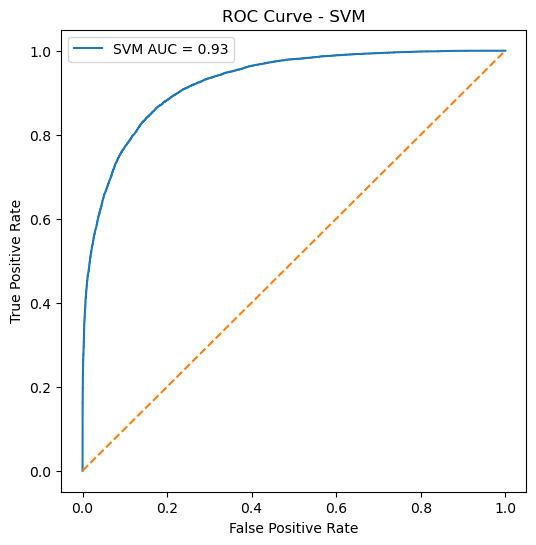

In [48]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Decision scores
y_scores_svm = svm.decision_function(X_test)

# ROC values
fpr_svm, tpr_svm, thresholds = roc_curve(y_test, y_scores_svm)

# AUC score
auc_svm = roc_auc_score(y_test, y_scores_svm)

# Plot ROC Curve
plt.figure(figsize=(6,6))

plt.plot(fpr_svm, tpr_svm, label=f'SVM AUC = {auc_svm:.2f}')

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()

plt.show()

### Results Comparison

In [60]:
#Combined Comparison Table
import pandas as pd

# Create comparison table
results = pd.DataFrame({
    'Model': ['KNN', 'Naive Bayes', 'SVM'],
    
    'Accuracy': [accuracy_knn, accuracy_nb, accuracy_svm],
    
    'Precision': [precision_knn, precision_nb, precision_svm],
    
    'Recall/TPR': [ recall_knn, recall_nb, recall_svm],
    
    'F1-Score': [ f1_knn, f1_nb, f1_svm],
    
    'AUC': [ auc_knn, auc_nb, auc_svm]
})

print(results)

         Model  Accuracy  Precision  Recall/TPR  F1-Score       AUC
0          KNN  0.801867   0.814265    0.734819  0.772505  0.861788
1  Naive Bayes  0.826167   0.826223    0.785496  0.805345  0.898045
2          SVM  0.845133   0.834560    0.825324  0.829917  0.925948


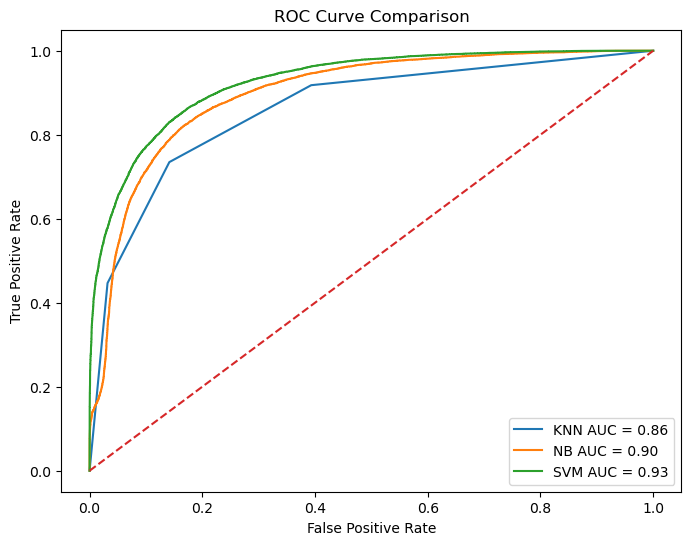

In [58]:
#Combined ROC Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# KNN ROC
plt.plot(fpr_knn, tpr_knn, label=f'KNN AUC = {auc_knn:.2f}')

# NB ROC
plt.plot(fpr_nb, tpr_nb, label=f'NB AUC = {auc_nb:.2f}')

# SVM ROC
plt.plot(fpr_svm, tpr_svm, label=f'SVM AUC = {auc_svm:.2f}')

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()